In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk vaderSentiment openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Load Dataset
df = pd.read_csv("imdb_top_1000.csv")

df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


# DATA CLEANING

In [2]:
# Remove nulls
df = df.dropna()

# Convert Gross to numeric
df['Gross'] = df['Gross'].str.replace(',', '')
df['Gross'] = pd.to_numeric(df['Gross'], errors='coerce')

df = df.dropna(subset=['Gross'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 997
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    714 non-null    object 
 1   Series_Title   714 non-null    object 
 2   Released_Year  714 non-null    object 
 3   Certificate    714 non-null    object 
 4   Runtime        714 non-null    object 
 5   Genre          714 non-null    object 
 6   IMDB_Rating    714 non-null    float64
 7   Overview       714 non-null    object 
 8   Meta_score     714 non-null    float64
 9   Director       714 non-null    object 
 10  Star1          714 non-null    object 
 11  Star2          714 non-null    object 
 12  Star3          714 non-null    object 
 13  Star4          714 non-null    object 
 14  No_of_Votes    714 non-null    int64  
 15  Gross          714 non-null    int64  
dtypes: float64(2), int64(2), object(12)
memory usage: 94.8+ KB


# SENTIMENT ANALYSIS USING VADER

In [3]:
analyzer = SentimentIntensityAnalyzer()

df['Sentiment_Score'] = df['Overview'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

df[['Series_Title', 'Sentiment_Score']].head()

,Series_Title,Sentiment_Score
0,The Shawshank Redemption,-0.4019
1,The Godfather,-0.6705
2,The Dark Knight,-0.8176
3,The Godfather: Part II,-0.4767
4,12 Angry Men,0.5423


# GENRE-WISE SENTIMENT VISUAL

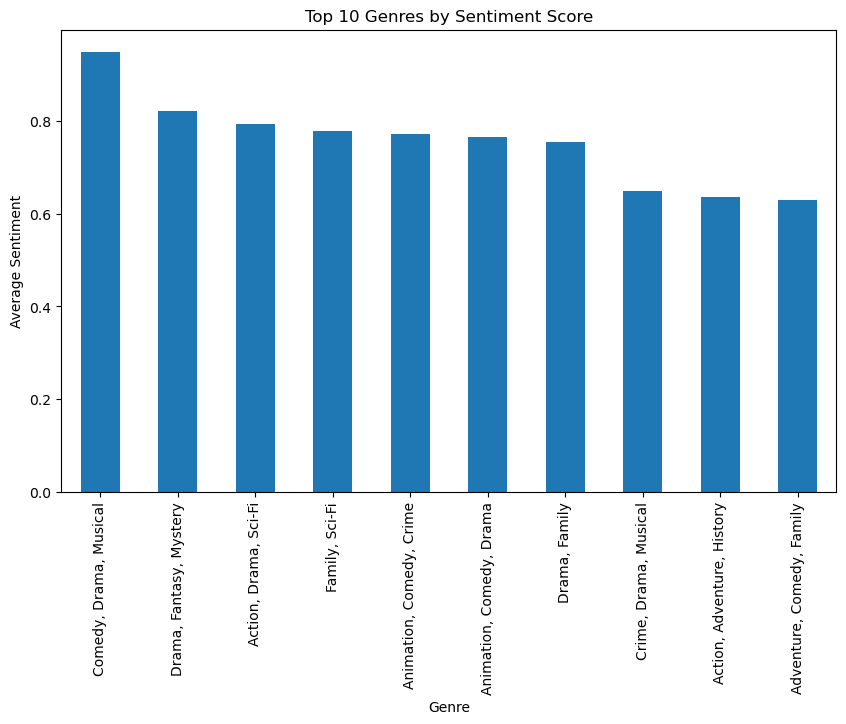

In [4]:
genre_sentiment = df.groupby('Genre')['Sentiment_Score'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
genre_sentiment.head(10).plot(kind='bar')
plt.title("Top 10 Genres by Sentiment Score")
plt.ylabel("Average Sentiment")
plt.show()

# PREDICTIVE MODEL (Regression)

# We predict Box Office Gross using:

# IMDB Rating

# Votes

# Sentiment Score

In [5]:
X = df[['IMDB_Rating', 'No_of_Votes', 'Sentiment_Score']]
y = df['Gross']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("R2 Score:", r2_score(y_test, predictions))
print("MSE:", mean_squared_error(y_test, predictions))

R2 Score: 0.3835765280192466
MSE: 8210815354112559.0


# SUCCESS CLASSIFICATION

In [6]:
def classify_success(gross):
    if gross > 500000000:
        return "Blockbuster"
    elif gross > 100000000:
        return "Hit"
    elif gross > 50000000:
        return "Average"
    else:
        return "Flop"

df['Success_Category'] = df['Gross'].apply(classify_success)

df['Success_Category'].value_counts()

Success_Category
Flop           419
Hit            178
Average        108
Blockbuster      9
Name: count, dtype: int64